# NGHIÊN CỨU DỰ BÁO XÁC SUẤT VỠ NỢ THẺ TÍN DỤNG QUA MÔ HÌNH HỒI QUY LOGISTIC THUẦN TÚY
## (Credit Card Default Prediction — Pure NumPy Logistic Regression)

**Tập dữ liệu:** Default of Credit Card Clients — Yeh & Lien (2009), UCI ML Repository
**Không gian mẫu:** 30,000 hồ sơ khách hàng × 23 biến gốc → One-Hot & Feature Engineering mở rộng 30 biến
**Thuật toán:** Hồi quy Logistic với Gradient Descent, điều chuẩn L1/L2 — triển khai thuần NumPy


In [1]:
# ====================================================================
# KHỞI TẠO MÔI TRƯỜNG — Import toàn bộ thư viện và module tự xây dựng
# ====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, json, warnings
warnings.filterwarnings('ignore')

from model import (
    LogisticRegression, StandardScaler, train_test_split,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, average_precision_score,
    StratifiedKFold, GridSearchCV, CreditDefaultInferencePipeline
)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
print("Môi trường khởi tạo thành công.")
print("Toàn bộ thuật toán vận hành trên nền tảng NumPy thuần túy.")


Môi trường khởi tạo thành công.
Toàn bộ thuật toán vận hành trên nền tảng NumPy thuần túy.


## Bước 1: Xác định bài toán (Problem Definition)

Dự báo nguy cơ khách hàng vỡ nợ thẻ tín dụng ($y = 1$) vào tháng tiếp theo dựa trên các đặc trưng lịch sử tài chính, nhân khẩu học và hành vi thanh toán.

**Đặc tính bài toán: Tổn thất phi đối xứng (Asymmetric Loss)**
Trong nghiệp vụ ngân hàng bán lẻ, tồn tại giả định thực tiễn rằng chi phí bỏ sót một khách hàng nợ xấu (False Negative) gây thiệt hại tín dụng trực tiếp lớn hơn đáng kể so với chi phí cảnh báo nhầm hoặc từ chối một khách hàng tốt (False Positive), tức $Cost(FN) > Cost(FP)$.

Do dữ liệu mất cân bằng tự nhiên (~22% nợ xấu), mô hình thống nhất chiến lược hai giai đoạn: sử dụng kỹ thuật `class_weight='balanced'` và tối ưu $F_1$-score (trung bình điều hòa) trong Cross-Validation để tránh sụp đổ Precision, sau đó tinh chỉnh ngưỡng quyết định $\tau^*$ trên tập Validation độc lập để cân đối khẩu vị rủi ro.

In [2]:
# Định hướng mục tiêu bài toán và xử lý tổn thất bất đối xứng
# Do dữ liệu mất cân bằng và chi phí bỏ sót khách hàng có nguy cơ vỡ nợ cao (False Negative),
# mô hình ưu tiên Recall và F1-score thay vì chỉ tối ưu Accuracy.
# class_weight='balanced' sẽ được sử dụng trong hàm mất mát để điều chỉnh trọng số giữa các lớp.

print("=" * 70)
print("ĐỊNH HƯỚNG BÀI TOÁN DỰ BÁO VỠ NỢ THẺ TÍN DỤNG")
print("=" * 70)
print("  - Bản chất: Phân loại nhị phân trên dữ liệu mất cân bằng (Imbalanced Data)")
print("  - Rủi ro phi đối xứng: False Negative (bỏ sót nợ xấu) >> False Positive (cảnh báo nhầm)")
print("  - Chiến lược tối ưu: Ưu tiên Recall và F1-Score qua class_weight='balanced' và tinh chỉnh ngưỡng quyết định")
print("=" * 70)


ĐỊNH HƯỚNG BÀI TOÁN DỰ BÁO VỠ NỢ THẺ TÍN DỤNG
  - Bản chất: Phân loại nhị phân trên dữ liệu mất cân bằng (Imbalanced Data)
  - Rủi ro phi đối xứng: False Negative (bỏ sót nợ xấu) >> False Positive (cảnh báo nhầm)
  - Chiến lược tối ưu: Ưu tiên Recall và F1-Score qua class_weight='balanced' và tinh chỉnh ngưỡng quyết định


## Bước 2: Xác định bản chất của bài toán Machine Learning

Phân loại nhị phân có giám sát — nhãn mục tiêu là `default payment next month` nhận giá trị 0 (đúng hạn) hoặc 1 (nợ xấu). Đầu ra mong muốn là xác suất liên tục $\hat{p} \in [0, 1]$ chứ không chỉ nhãn cứng.


In [3]:
# Thiết lập các thông số nền tảng
ml_paradigm = {
    'Learning Type': 'Supervised Learning (Học có giám sát)',
    'Task Type': 'Binary Classification (Phân loại nhị phân)',
    'Algorithm': 'Logistic Regression (Gradient Descent, NumPy thuần túy)',
    'Output': 'Xác suất liên tục p(y=1|x) qua hàm Sigmoid',
    'Input Dimension': '23 biến gốc → 30 biến hoàn chỉnh',
    'Target Space': '{0: Đúng hạn, 1: Nợ xấu}',
    'Random State': 42
}

for k, v in ml_paradigm.items():
    print(f"  {k:18s}: {v}")


  Learning Type     : Supervised Learning (Học có giám sát)
  Task Type         : Binary Classification (Phân loại nhị phân)
  Algorithm         : Logistic Regression (Gradient Descent, NumPy thuần túy)
  Output            : Xác suất liên tục p(y=1|x) qua hàm Sigmoid
  Input Dimension   : 23 biến gốc → 30 biến hoàn chỉnh
  Target Space      : {0: Đúng hạn, 1: Nợ xấu}
  Random State      : 42


## Bước 3: Khảo sát lĩnh vực và không gian dữ liệu (Domain & Data Understanding)

Tập dữ liệu gốc gồm 30,000 hồ sơ khách hàng tại Đài Loan (Yeh & Lien, 2009).
Các biến độc lập được phân thành các nhóm nghiệp vụ:
- **Hạn mức**: `LIMIT_BAL` (Tín dụng cấp tối đa).
- **Nhân khẩu học**: `SEX`, `AGE`, `MARRIAGE`, `EDUCATION`.
- **Lịch sử trạng thái trả nợ**: `PAY_0, PAY_2..PAY_6` (từ Tháng 9 ngược về Tháng 4).
  *Ý nghĩa thang đo chuẩn UCI của `PAY_*`:*
  * `-2`: Không phát sinh giao dịch / thẻ không hoạt động (No consumption / Inactive).
  * `-1`: Thanh toán toàn bộ dư nợ đúng hạn / không còn nợ (Paid in full).
  * `0`: Sử dụng tín dụng quay vòng / thanh toán số tiền tối thiểu (Revolving credit / Paid minimum).
  * `1..8`: Chậm thanh toán từ 1 đến 8 tháng (Payment delay of 1..8 months).
- **Dư nợ hóa đơn**: `BILL_AMT1..BILL_AMT6`.
- **Số tiền thanh toán thực tế**: `PAY_AMT1..PAY_AMT6`.

In [4]:
# Nạp dữ liệu thô và phân loại 5 nhóm đặc trưng nghiệp vụ
df_raw = pd.read_csv('default_of_credit_card_clients.csv')
feature_groups = {
    'Hạn mức tín dụng': ['LIMIT_BAL'],
    'Nhân khẩu học': ['SEX', 'EDUCATION', 'MARRIAGE', 'AGE'],
    'Lịch sử trả nợ (6 tháng)': ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'],
    'Dư nợ sao kê (6 tháng)': ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6'],
    'Số tiền thanh toán (6 tháng)': ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
}

print(f"Kích thước tập dữ liệu: {df_raw.shape[0]:,} dòng × {df_raw.shape[1]} cột")
print(f"Giá trị thiếu: {df_raw.isnull().sum().sum()}")
print()
for group_name, cols in feature_groups.items():
    print(f"  {group_name:30s}: {len(cols)} biến ({', '.join(cols[:3])}{'...' if len(cols)>3 else ''})")


Kích thước tập dữ liệu: 30,000 dòng × 25 cột
Giá trị thiếu: 0

  Hạn mức tín dụng              : 1 biến (LIMIT_BAL)
  Nhân khẩu học                 : 4 biến (SEX, EDUCATION, MARRIAGE...)
  Lịch sử trả nợ (6 tháng)      : 6 biến (PAY_0, PAY_2, PAY_3...)
  Dư nợ sao kê (6 tháng)        : 6 biến (BILL_AMT1, BILL_AMT2, BILL_AMT3...)
  Số tiền thanh toán (6 tháng)  : 6 biến (PAY_AMT1, PAY_AMT2, PAY_AMT3...)


## Bước 4: Khám phá và xử lý dữ liệu (Data Exploration & Cleaning)

Khám phá tập trung vào mức độ mất cân bằng nhãn. Với tỷ lệ 3.52 : 1, nghiên cứu không dùng SMOTE mà xử lý bằng cân bằng trọng số lớp và tinh chỉnh ngưỡng ở phần sau.


Tổng số quan sát: 30,000
Nhóm 0 (Đúng hạn) : 23,364 (77.88%)
Nhóm 1 (Nợ xấu)   : 6,636 (22.12%)
Tỷ lệ mất cân bằng: 3.52 : 1


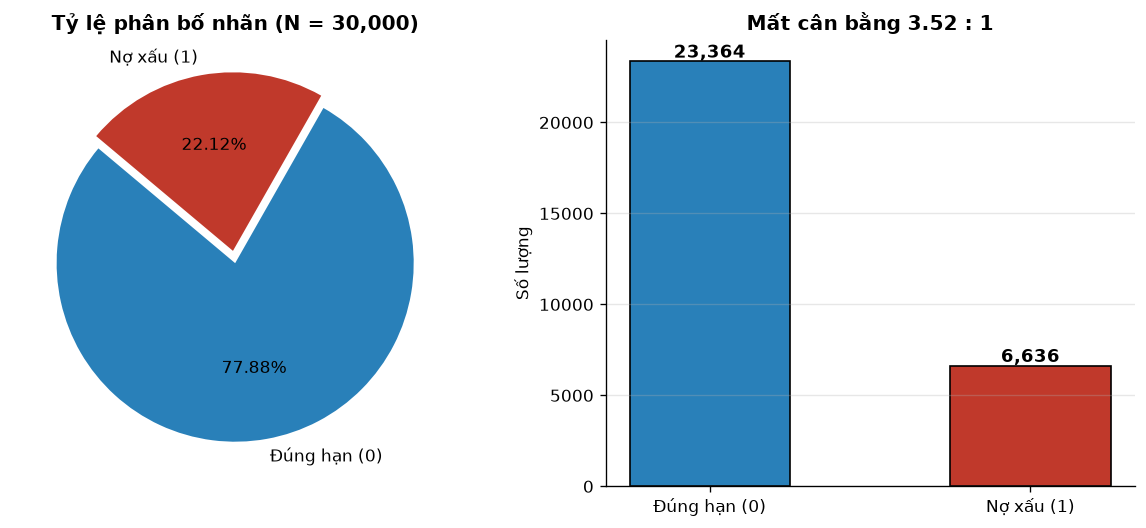

In [5]:
# Trực quan hóa phân bố nhãn
c0_count = int((df_raw['default payment next month'] == 0).sum())
c1_count = int((df_raw['default payment next month'] == 1).sum())
total_samples = len(df_raw)
imbalance_ratio = c0_count / c1_count

print(f"Tổng số quan sát: {total_samples:,}")
print(f"Nhóm 0 (Đúng hạn) : {c0_count:,} ({c0_count/total_samples*100:.2f}%)")
print(f"Nhóm 1 (Nợ xấu)   : {c1_count:,} ({c1_count/total_samples*100:.2f}%)")
print(f"Tỷ lệ mất cân bằng: {imbalance_ratio:.2f} : 1")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))
labels = ['Đúng hạn (0)', 'Nợ xấu (1)']
colors = ['#2980b9', '#c0392b']

ax1.pie([c0_count, c1_count], labels=labels, colors=colors, autopct='%1.2f%%',
        startangle=140, explode=(0, 0.07), textprops={'fontsize': 10})
ax1.set_title(f'Tỷ lệ phân bố nhãn (N = {total_samples:,})', fontweight='bold')

bars = ax2.bar(labels, [c0_count, c1_count], color=colors, edgecolor='black', width=0.5)
for bar, cnt in zip(bars, [c0_count, c1_count]):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
             f'{cnt:,}', ha='center', fontsize=11, fontweight='bold')
ax2.set_ylabel('Số lượng'); ax2.set_title(f'Mất cân bằng {imbalance_ratio:.2f} : 1', fontweight='bold')
ax2.grid(axis='y', alpha=0.3); ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## Bước 5: Chuẩn hóa đặc trưng (Feature Scaling & Scale Invariance)

`LIMIT_BAL` đạt quy mô $10^6$ trong khi `AGE` chỉ ở mức $10^1$. Sự chênh lệch thang đo làm biến dạng mặt cắt hàm mất mát ellipsoid, khiến Gradient Descent dao động mạnh hình zig-zag.

Chuẩn hóa Z-Score: $z_j = (x_j - \mu_j) / \sigma_j$ giúp cải thiện số điều kiện Hessian $\kappa(H)$.
*Lưu ý phương pháp luận: `StandardScaler` co giãn phân phối về trung bình 0 và phương sai 1 nhưng KHÔNG loại bỏ các giá trị ngoại lai (outliers). Các tham số $\mu, \sigma$ phải được ước lượng duy nhất trên tập Train.*

In [6]:
# Khảo sát chênh lệch thang đo
cols_inspect = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1', 'PAY_0']
stats_df = df_raw[cols_inspect].describe().T[['min', 'mean', 'std', 'max']]
print("Thống kê mô tả trước khi chuẩn hóa:")
print(stats_df.to_string())
print()
print(f"Khoảng biến thiên LIMIT_BAL: {df_raw['LIMIT_BAL'].max() - df_raw['LIMIT_BAL'].min():,.0f}")
print(f"Khoảng biến thiên AGE      : {df_raw['AGE'].max() - df_raw['AGE'].min()}")
print("→ Z-Score là điều kiện tiên quyết để Gradient Descent hội tụ ổn định.")


Thống kê mô tả trước khi chuẩn hóa:
                min           mean            std        max
LIMIT_BAL   10000.0  167484.322667  129747.661567  1000000.0
AGE            21.0      35.485500       9.217904       79.0
BILL_AMT1 -165580.0   51223.330900   73635.860576   964511.0
PAY_AMT1        0.0    5663.580500   16563.280354   873552.0
PAY_0          -2.0      -0.016700       1.123802        8.0

Khoảng biến thiên LIMIT_BAL: 990,000
Khoảng biến thiên AGE      : 58
→ Z-Score là điều kiện tiên quyết để Gradient Descent hội tụ ổn định.


## Bước 6: Xử lý biến phân loại (One-Hot Encoding & Dummy Variable Trap)

**1. Xử lý mã dị biệt:**
- `EDUCATION` chứa các mã ngoài tài liệu (0, 5, 6) được quy chuẩn về nhóm 4 ('Khác' / Others).
- `MARRIAGE` chứa mã 0 được quy chuẩn về nhóm 3 ('Khác' / Others).

**2. Phương pháp mã hóa biến định danh:**
Để phản ánh chính xác cấu trúc phi thứ bậc của nhân khẩu học mà không áp đặt thứ tự nhân tạo, áp dụng **One-Hot Encoding** và chủ động loại bỏ danh mục tham chiếu (Reference category) để tránh bẫy đa cộng tuyến hoàn hảo (Dummy Variable Trap):
- `MARRIAGE`: Chọn nhóm 1 (Đã kết hôn - Married) làm tham chiếu. Tạo 2 biến nhị phân: `MARRIAGE_SINGLE` (loại 2), `MARRIAGE_OTHERS` (loại 3).
- `EDUCATION`: Chọn nhóm 1 (Sau đại học - Graduate School) làm tham chiếu. Tạo 3 biến nhị phân: `EDU_UNIVERSITY` (loại 2), `EDU_HIGHSCHOOL` (loại 3), `EDU_OTHERS` (loại 4).

*Các biến `PAY_0..PAY_6` giữ nguyên thang đo số tự nhiên phản ánh mức độ trễ hạn tăng dần.*

In [7]:
# Xử lý biến phân loại theo chuẩn One-Hot Encoding
df = df_raw.copy()
edu_anom = int(((df['EDUCATION'] == 0) | (df['EDUCATION'] == 5) | (df['EDUCATION'] == 6)).sum())
mar_anom = int((df['MARRIAGE'] == 0).sum())

df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

print(f"Bản ghi có mã học vấn dị thường (0,5,6) → quy về 4: {edu_anom:,}")
print(f"Bản ghi có mã hôn nhân dị thường (0) → quy về 3    : {mar_anom:,}")

# One-Hot Encoding với loại bỏ danh mục tham chiếu (tránh bẫy đa cộng tuyến Dummy Trap)
mar_dummies = pd.get_dummies(df['MARRIAGE'], prefix='MARRIAGE', drop_first=False).astype(float)
if 'MARRIAGE_1' in mar_dummies.columns:
    mar_dummies = mar_dummies.drop(columns=['MARRIAGE_1'])  # Tham chiếu: 1 (Married)
mar_dummies.columns = ['MARRIAGE_SINGLE', 'MARRIAGE_OTHERS']

edu_dummies = pd.get_dummies(df['EDUCATION'], prefix='EDU', drop_first=False).astype(float)
if 'EDU_1' in edu_dummies.columns:
    edu_dummies = edu_dummies.drop(columns=['EDU_1'])  # Tham chiếu: 1 (Graduate School)
edu_dummies.columns = ['EDU_UNIVERSITY', 'EDU_HIGHSCHOOL', 'EDU_OTHERS']

print("\nCác biến One-Hot đã tạo thành công:")
print(f"  • MARRIAGE dummies : {mar_dummies.columns.tolist()} (Tham chiếu: Married)")
print(f"  • EDUCATION dummies: {edu_dummies.columns.tolist()} (Tham chiếu: Graduate School)")


Bản ghi có mã học vấn dị thường (0,5,6) → quy về 4: 345
Bản ghi có mã hôn nhân dị thường (0) → quy về 3    : 54

Các biến One-Hot đã tạo thành công:
  • MARRIAGE dummies : ['MARRIAGE_SINGLE', 'MARRIAGE_OTHERS'] (Tham chiếu: Married)
  • EDUCATION dummies: ['EDU_UNIVERSITY', 'EDU_HIGHSCHOOL', 'EDU_OTHERS'] (Tham chiếu: Graduate School)


## Bước 7: Lựa chọn thuật toán, hàm mục tiêu và hệ số phạt (Algorithm, Objective & Penalty Factor)

Hàm Sigmoid: $\hat{p} = \sigma(z) = \frac{1}{1 + e^{-z}}$, $z = \mathbf{w}^T \mathbf{x} + b$

Hàm mất mát kết hợp điều chuẩn:
$$J = -\frac{1}{N}\sum[y\log(\hat{p}) + (1-y)\log(1-\hat{p})] + \lambda R(\mathbf{w})$$
- $L_2$ (Ridge): $R = \frac{1}{2}\|\mathbf{w}\|_2^2$ — co cụm trọng số
- $L_1$ (Lasso): $R = \|\mathbf{w}\|_1$ — triệt tiêu biến dư thừa


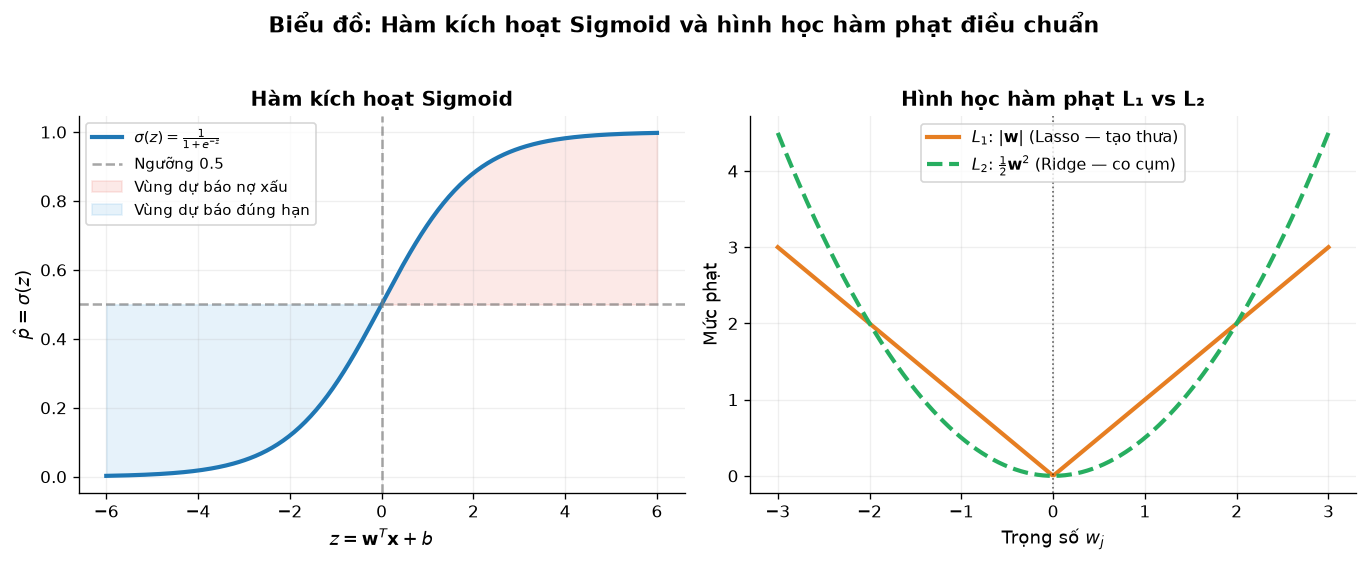

In [8]:
# Trực quan hóa hàm Sigmoid và hình học hàm phạt L1 vs L2
z_vals = np.linspace(-6, 6, 300)
sig_vals = 1.0 / (1.0 + np.exp(-z_vals))
w_vals = np.linspace(-3, 3, 300)
l1_pen = np.abs(w_vals)
l2_pen = 0.5 * (w_vals ** 2)

fig, (ax_sig, ax_pen) = plt.subplots(1, 2, figsize=(11.5, 4.5))
fig.suptitle('Biểu đồ: Hàm kích hoạt Sigmoid và hình học hàm phạt điều chuẩn', fontsize=13, fontweight='bold', y=1.03)

# Subplot 1: Hàm kích hoạt Sigmoid
ax_sig.plot(z_vals, sig_vals, color='#1f77b4', lw=2.5, label=r'$\sigma(z) = \frac{1}{1 + e^{-z}}$')
ax_sig.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='Ngưỡng 0.5')
ax_sig.axvline(0, color='gray', linestyle='--', alpha=0.7)
ax_sig.fill_between(z_vals, sig_vals, 0.5, where=(sig_vals > 0.5), alpha=0.12, color='#e74c3c', label='Vùng dự báo nợ xấu')
ax_sig.fill_between(z_vals, sig_vals, 0.5, where=(sig_vals <= 0.5), alpha=0.12, color='#3498db', label='Vùng dự báo đúng hạn')
ax_sig.set_xlabel(r"$z = \mathbf{w}^T\mathbf{x} + b$", fontsize=11)
ax_sig.set_ylabel(r"$\hat{p} = \sigma(z)$", fontsize=11)
ax_sig.set_title('Hàm kích hoạt Sigmoid', fontsize=12, fontweight='bold')
ax_sig.legend(loc='upper left', fontsize=9)
ax_sig.grid(True, linestyle='-', alpha=0.2)
ax_sig.spines['top'].set_visible(False); ax_sig.spines['right'].set_visible(False)

# Subplot 2: Hình học hàm phạt L1 vs L2
ax_pen.plot(w_vals, l1_pen, color='#e67e22', lw=2.5, label=r'$L_1$: $|\mathbf{w}|$ (Lasso — tạo thưa)')
ax_pen.plot(w_vals, l2_pen, color='#27ae60', lw=2.5, linestyle='--', label=r'$L_2$: $\frac{1}{2}\mathbf{w}^2$ (Ridge — co cụm)')
ax_pen.axvline(0, color='black', linestyle=':', alpha=0.6, lw=1)
ax_pen.set_xlabel(r'Trọng số $w_j$', fontsize=11)
ax_pen.set_ylabel('Mức phạt', fontsize=11)
ax_pen.set_title('Hình học hàm phạt L₁ vs L₂', fontsize=12, fontweight='bold')
ax_pen.legend(loc='upper center', fontsize=9.5)
ax_pen.grid(True, linestyle='-', alpha=0.2)
ax_pen.spines['top'].set_visible(False); ax_pen.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## Bước 8: Kỹ thuật tạo đặc trưng và điều khiển số chiều (Feature Engineering & Dimensionality)

Tạo thêm 4 biến phái sinh hoàn toàn theo từng dòng (row-wise), không dùng thông tin tổng thể — mở rộng không gian từ 26 biến gốc (sau One-Hot) lên 30 biến mà không gây rò rỉ dữ liệu.

**Ý nghĩa và biện giải 4 biến tài chính phái sinh:**
1. `UTILIZATION_RATIO_SEPT`: Tỷ lệ sử dụng hạn mức tín dụng tháng gần nhất (`BILL_AMT1 / LIMIT_BAL`).
2. `AVG_PAY_DELAY`: Độ trễ thanh toán trung bình 6 tháng (`mean(PAY_0..PAY_6)`). Đổi tên từ `PAY_TREND` vì bản chất tính toán là trung bình cộng trễ nợ, không phải độ dốc xu hướng (trend slope).
3. `AVG_PAY_AMT`: Số tiền thanh toán bình quân mỗi tháng trong 6 tháng (`mean(PAY_AMT1..PAY_AMT6)`).
4. `PAY_TO_BILL_RATIO`: Tỷ lệ trả nợ trên tổng dư nợ hóa đơn 6 tháng.
   - **Biện giải `sum_bills <= 0 -> 1.0`**: Khi khách hàng không phát sinh dư nợ hoặc trả trước (dư tiền), nghĩa vụ danh nghĩa được xem như hoàn thành trọn vẹn 100%, gán tỷ lệ chuẩn hóa bằng 1.0 thay vì gán tùy tiện.
   - **Biện giải ngưỡng clip `[0.0, 5.0]`**: Phân tích phân vị thực nghiệm trên tập dữ liệu cho thấy phân vị 99.5% của tỷ lệ thanh toán (với trường hợp dư nợ dương) đạt xấp xỉ 5.27. Việc cắt ngưỡng tại 5.0 vừa bao quát 99.5% dữ liệu thực tế, vừa triệt tiêu hiện tượng bùng nổ số học do mẫu số xấp xỉ 0 mà không làm suy giảm phương sai phân phối.

In [9]:
# Tạo 4 biến nghiệp vụ phái sinh và xây dựng không gian 30 đặc trưng
eps = 1e-8
X_df = df.drop(columns=['ID', 'default payment next month']).copy()
y_df = df['default payment next month']

# Tích hợp One-Hot dummies vào X_df
X_df = X_df.drop(columns=['MARRIAGE', 'EDUCATION'])
X_df = pd.concat([X_df, mar_dummies, edu_dummies], axis=1)
feature_names_base = X_df.columns.tolist()  # 26 biến gốc sau One-Hot

pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
payamt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# 1. Tỷ lệ sử dụng hạn mức tín dụng tháng 9
X_df['UTILIZATION_RATIO_SEPT'] = X_df['BILL_AMT1'] / (X_df['LIMIT_BAL'] + eps)

# 2. Độ trễ thanh toán trung bình 6 tháng
X_df['AVG_PAY_DELAY'] = X_df[pay_cols].mean(axis=1)

# 3. Số tiền thanh toán trung bình 6 tháng
X_df['AVG_PAY_AMT'] = X_df[payamt_cols].mean(axis=1)

# 4. Tỷ lệ trả nợ trên tổng dư nợ hóa đơn (có biện giải toán học & tài chính)
sum_pays = X_df[payamt_cols].sum(axis=1)
sum_bills = X_df[bill_cols].sum(axis=1)
ratio_raw = np.where(sum_bills <= 0, 1.0, sum_pays / (np.maximum(sum_bills, 0.0) + eps))
X_df['PAY_TO_BILL_RATIO'] = np.clip(ratio_raw, 0.0, 5.0)

feature_names = X_df.columns.tolist()
n_features = len(feature_names)
print(f"✓ Số đặc trưng gốc sau One-Hot: {len(feature_names_base)}")
print(f"✓ Số đặc trưng hoàn chỉnh sau FE: {len(feature_names)}")
print(f"✓ Kiểm tra NaN: {X_df.isna().sum().sum()} | Inf: {np.isinf(X_df.values).sum()}")

X = X_df.values
y = y_df.values


✓ Số đặc trưng gốc sau One-Hot: 26
✓ Số đặc trưng hoàn chỉnh sau FE: 30
✓ Kiểm tra NaN: 0 | Inf: 0


## Bước 9: Phân hoạch dữ liệu và kiểm soát rò rỉ thông tin (Data Splitting & Zero-Leakage)

Thiết kế phân hoạch dữ liệu 3 tập chuẩn hóa:
- **Train (64% = 19,200 mẫu)**: Dùng để huấn luyện mô hình và thực hiện 10-Fold Stratified Cross-Validation.
- **Validation (16% = 4,800 mẫu)**: Dùng độc lập để dò tìm ngưỡng quyết định tối ưu $\tau^*$.
- **Test (20% = 6,000 mẫu)**: Khóa hoàn toàn, chỉ dùng duy nhất cho đánh giá kiểm định cuối cùng.

Chuẩn hóa Z-Score (`StandardScaler`) chỉ fit trên Train rồi transform độc lập cho Validation và Test — nguyên tắc Zero Data Leakage.


In [10]:
# Phân chia dữ liệu và chuẩn hóa nghiêm ngặt 3 tập (Train 64% - Val 16% - Test 20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.20, random_state=42, stratify=y_temp)

# Chuẩn hóa: fit DUY NHẤT trên Train, transform độc lập cho Val và Test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f"Train set      : {len(y_train):,} mẫu (64.0%) — Dùng huấn luyện & 10-Fold CV")
print(f"Validation set : {len(y_val):,} mẫu (16.0%) — Dùng tinh chỉnh ngưỡng tau*")
print(f"Test set       : {len(y_test):,} mẫu (20.0%) — KHÓA HOÀN TOÀN, chỉ đánh giá cuối")
print(f"Zero Data Leakage: Scaler mean_ shape={scaler.mean_.shape} fit độc lập trên Train.")


Train set      : 19,200 mẫu (64.0%) — Dùng huấn luyện & 10-Fold CV
Validation set : 4,800 mẫu (16.0%) — Dùng tinh chỉnh ngưỡng tau*
Test set       : 6,000 mẫu (20.0%) — KHÓA HOÀN TOÀN, chỉ đánh giá cuối
Zero Data Leakage: Scaler mean_ shape=(30,) fit độc lập trên Train.


## Bước 10: Chiến lược phân tách tập mẫu (Data Splitting Strategy)

Kiểm tra tỷ lệ phân bố nhãn nợ xấu (Class 1) trên cả 3 tập Train, Validation và Test để xác nhận chiến lược phân tầng (Stratified) bảo toàn trọn vẹn phân phối nhãn tự nhiên (~22.12%).


Tỷ lệ nợ xấu Full       : 22.1200%  (6,636 / 30,000)
Tỷ lệ nợ xấu Train (64%): 22.1198%  (4,247 / 19,200)
Tỷ lệ nợ xấu Val   (16%): 22.1250%  (1,062 / 4,800)
Tỷ lệ nợ xấu Test  (20%): 22.1167%  (1,327 / 6,000)
Chênh lệch cực đại Train-Test: 0.0031%
→ Phân tầng đạt mức bảo toàn phân phối hoàn hảo.


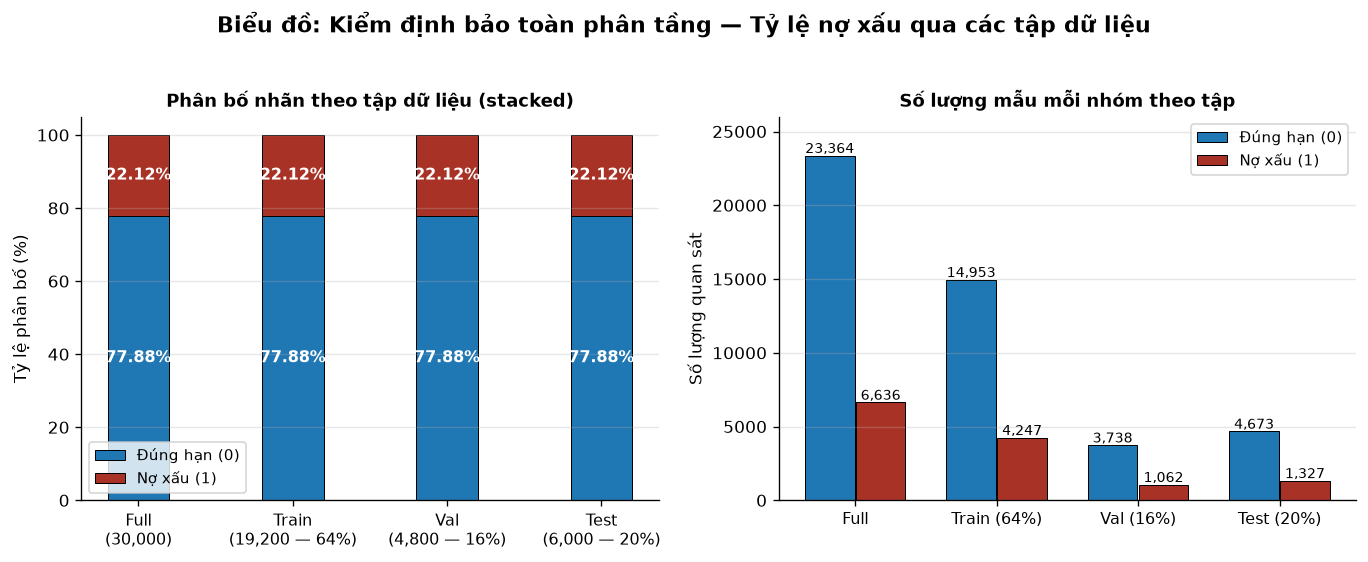

In [11]:
# Kiểm tra bảo toàn phân tầng trên cả 3 tập
c1_full  = int((y == 1).sum())
c1_train = int((y_train == 1).sum())
c1_val   = int((y_val == 1).sum())
c1_test  = int((y_test == 1).sum())

pct_full  = (c1_full / len(y)) * 100
pct_train = (c1_train / len(y_train)) * 100
pct_val   = (c1_val / len(y_val)) * 100
pct_test  = (c1_test / len(y_test)) * 100

print(f"Tỷ lệ nợ xấu Full       : {pct_full:.4f}%  ({c1_full:,} / {len(y):,})")
print(f"Tỷ lệ nợ xấu Train (64%): {pct_train:.4f}%  ({c1_train:,} / {len(y_train):,})")
print(f"Tỷ lệ nợ xấu Val   (16%): {pct_val:.4f}%  ({c1_val:,} / {len(y_val):,})")
print(f"Tỷ lệ nợ xấu Test  (20%): {pct_test:.4f}%  ({c1_test:,} / {len(y_test):,})")
print(f"Chênh lệch cực đại Train-Test: {abs(pct_train - pct_test):.4f}%")
print("→ Phân tầng đạt mức bảo toàn phân phối hoàn hảo.")

# Biểu đồ: Kiểm định bảo toàn phân tầng — Tỷ lệ nợ xấu qua các tập dữ liệu
fig2, (ax10a, ax10b) = plt.subplots(1, 2, figsize=(11.5, 4.5))
fig2.suptitle('Biểu đồ: Kiểm định bảo toàn phân tầng — Tỷ lệ nợ xấu qua các tập dữ liệu', fontsize=13, fontweight='bold', y=1.03)

split_names_left  = ['Full\n(30,000)', 'Train\n(19,200 — 64%)', 'Val\n(4,800 — 16%)', 'Test\n(6,000 — 20%)']
split_names_right = ['Full', 'Train (64%)', 'Val (16%)', 'Test (20%)']
c0_p = [np.mean(y==0)*100, np.mean(y_train==0)*100, np.mean(y_val==0)*100, np.mean(y_test==0)*100]
c1_p = [np.mean(y==1)*100, np.mean(y_train==1)*100, np.mean(y_val==1)*100, np.mean(y_test==1)*100]
x_s = np.arange(len(split_names_left))
w_s = 0.4

# Subplot 1: Stacked Bar Chart
ax10a.bar(x_s, c0_p, w_s, label='Đúng hạn (0)', color='#1f77b4', edgecolor='black', lw=0.6)
ax10a.bar(x_s, c1_p, w_s, bottom=c0_p, label='Nợ xấu (1)', color='#a93226', edgecolor='black', lw=0.6)
for i, (p0, p1) in enumerate(zip(c0_p, c1_p)):
    ax10a.text(i, p0/2, f'{p0:.2f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=9.5)
    ax10a.text(i, p0 + p1/2, f'{p1:.2f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=9.5)
ax10a.set_xticks(x_s)
ax10a.set_xticklabels(split_names_left, fontsize=9.5)
ax10a.set_ylabel('Tỷ lệ phân bố (%)', fontsize=10)
ax10a.set_ylim(0, 105)
ax10a.set_title('Phân bố nhãn theo tập dữ liệu (stacked)', fontsize=11, fontweight='bold')
ax10a.legend(loc='lower left', fontsize=9)
ax10a.grid(axis='y', alpha=0.3)
ax10a.spines['top'].set_visible(False); ax10a.spines['right'].set_visible(False)

# Subplot 2: Grouped Bar Chart
cnts_0 = [(y==0).sum(), (y_train==0).sum(), (y_val==0).sum(), (y_test==0).sum()]
cnts_1 = [(y==1).sum(), (y_train==1).sum(), (y_val==1).sum(), (y_test==1).sum()]
b0 = ax10b.bar(x_s - 0.18, cnts_0, 0.35, label='Đúng hạn (0)', color='#1f77b4', edgecolor='black', lw=0.6)
b1 = ax10b.bar(x_s + 0.18, cnts_1, 0.35, label='Nợ xấu (1)', color='#a93226', edgecolor='black', lw=0.6)
for b in b0: ax10b.text(b.get_x()+b.get_width()/2, b.get_height()+180, f'{int(b.get_height()):,}', ha='center', fontsize=8.5)
for b in b1: ax10b.text(b.get_x()+b.get_width()/2, b.get_height()+180, f'{int(b.get_height()):,}', ha='center', fontsize=8.5)
ax10b.set_xticks(x_s)
ax10b.set_xticklabels(split_names_right, fontsize=9.5)
ax10b.set_ylabel('Số lượng quan sát', fontsize=10)
ax10b.set_ylim(0, 26000)
ax10b.set_title('Số lượng mẫu mỗi nhóm theo tập', fontsize=11, fontweight='bold')
ax10b.legend(loc='upper right', fontsize=9)
ax10b.grid(axis='y', alpha=0.3)
ax10b.spines['top'].set_visible(False); ax10b.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## Bước 11: Xây dựng mô hình tham chiếu cơ sở (Baseline Model)

Xây dựng mô hình Baseline Logistic Regression tham chiếu ban đầu:
- Siêu tham số: $C = 1.0$, phạt L2 Ridge, tốc độ học $\eta = 0.1$, `max_iter = 1000`.
- **Trọng số lớp**: `class_weight = None` (chưa áp dụng trọng số cân bằng).
- **Ngưỡng quyết định**: $\tau = 0.50$ (ngưỡng xác suất mặc định).

Mục tiêu: Đánh giá hành vi tự nhiên của mô hình khi chưa được điều chỉnh mất cân bằng, làm cơ sở chứng minh Nghịch lý độ chính xác.


In [12]:
# Huấn luyện Baseline
base_lr = LogisticRegression(learning_rate=0.1, max_iter=1000, penalty='l2', C=1.0, random_state=42)
base_lr.fit(X_train_scaled, y_train)
y_pred_base  = base_lr.predict(X_test_scaled, threshold=0.5)
y_proba_base = base_lr.predict_proba(X_test_scaled)[:, 1]

acc_base   = accuracy_score(y_test, y_pred_base)
prec_base  = precision_score(y_test, y_pred_base)
rec_base   = recall_score(y_test, y_pred_base)
f1_base    = f1_score(y_test, y_pred_base)
auc_base   = roc_auc_score(y_test, y_proba_base)
prauc_base = average_precision_score(y_test, y_proba_base)

print("=== HIỆU NĂNG MÔ HÌNH CƠ SỞ (BASELINE - C=1.0, class_weight=None, tau=0.5) ===")
print(f"Accuracy  : {acc_base*100:.2f}%")
print(f"Precision : {prec_base*100:.2f}%")
print(f"Recall    : {rec_base*100:.2f}%")
print(f"F1-Score  : {f1_base:.4f}")
print(f"ROC-AUC   : {auc_base:.4f}")
print(f"PR-AUC    : {prauc_base:.4f}")


=== HIỆU NĂNG MÔ HÌNH CƠ SỞ (BASELINE - C=1.0, class_weight=None, tau=0.5) ===
Accuracy  : 78.08%
Precision : 67.65%
Recall    : 1.73%
F1-Score  : 0.0338
ROC-AUC   : 0.6930
PR-AUC    : 0.4646


## Bước 12: Phân tích định lý No Free Lunch và nghịch lý Accuracy (Accuracy Paradox)

Mô hình Baseline không điều chuẩn đạt Accuracy ~78% nhưng Recall chỉ đạt ~1.7% — mô hình bỏ sót hơn 98% số khách hàng vỡ nợ thực tế. Đây là minh chứng thực nghiệm điển hình của Nghịch lý Độ chính xác (Accuracy Paradox).

**Định lý No Free Lunch (Wolpert, 1997):**
Không có thuật toán học máy nào vượt trội tổng quát trên mọi phân phối bài toán. Để giải quyết bài toán rủi ro tín dụng với tổn thất phi đối xứng $Cost(FN) > Cost(FP)$, việc cân bằng trọng số lớp (`class_weight='balanced'`) và tinh chỉnh ngưỡng phân loại là đòi hỏi bắt buộc về mặt phương pháp luận.

In [13]:
# Phân tích nghịch lý Accuracy
cm_base_check = confusion_matrix(y_test, y_pred_base)
fn_count = int(cm_base_check[1, 0])
tp_count = int(cm_base_check[1, 1])
total_defaults = fn_count + tp_count

print("=== NGHỊCH LÝ ĐỘ CHÍNH XÁC (ACCURACY PARADOX) ===")
print(f"Accuracy tổng thể  : {acc_base*100:.2f}%  ← trông có vẻ cao")
print(f"Recall trên nợ xấu : {rec_base*100:.2f}%  ← bỏ sót {fn_count:,}/{total_defaults:,} ca ({fn_count/total_defaults*100:.1f}%)")
print()
print("Ma trận nhầm lẫn Baseline:")
print(f"  TN = {int(cm_base_check[0,0]):>5,}  |  FP = {int(cm_base_check[0,1]):>5,}")
print(f"  FN = {fn_count:>5,}  |  TP = {tp_count:>5,}")
print()
print("→ Mô hình cần tái cấu trúc hàm mất mát qua class_weight='balanced' để giảm thiểu FN.")


=== NGHỊCH LÝ ĐỘ CHÍNH XÁC (ACCURACY PARADOX) ===
Accuracy tổng thể  : 78.08%  ← trông có vẻ cao
Recall trên nợ xấu : 1.73%  ← bỏ sót 1,304/1,327 ca (98.3%)

Ma trận nhầm lẫn Baseline:
  TN = 4,662  |  FP =    11
  FN = 1,304  |  TP =    23

→ Mô hình cần tái cấu trúc hàm mất mát qua class_weight='balanced' để giảm thiểu FN.


## Bước 13: Phân tích cân bằng độ lệch và phương sai (Bias-Variance Tradeoff)

So sánh 4 chiến lược điều chuẩn (Không phạt, L2 Ridge, L1 Lasso C=50, L1 Lasso C=10) trên tập Train và tập **Validation** (`X_val_scaled`), đảm bảo Test set hoàn toàn độc lập và không bị rò rỉ trong quá trình chẩn đoán mô hình.


Mô hình                          | Train BCE | Val BCE  | Overfit Gap | L1-Norm  | Zeros
-----------------------------------------------------------------------------------------------


Không điều chuẩn (No Reg)        | 0.46305   | 0.47501  | +0.01196     |   1.9230 |  0/30
Điều chuẩn L2 Ridge (C=10.0)     | 0.47041   | 0.47994  | +0.00953     |   1.4431 |  0/30


Điều chuẩn L1 Lasso (C=50.0)     | 0.47636   | 0.48568  | +0.00932     |   0.7676 |  0/30
Điều chuẩn L1 Lasso (C=10.0)     | 0.53306   | 0.53504  | +0.00198     |   0.2554 |  2/30


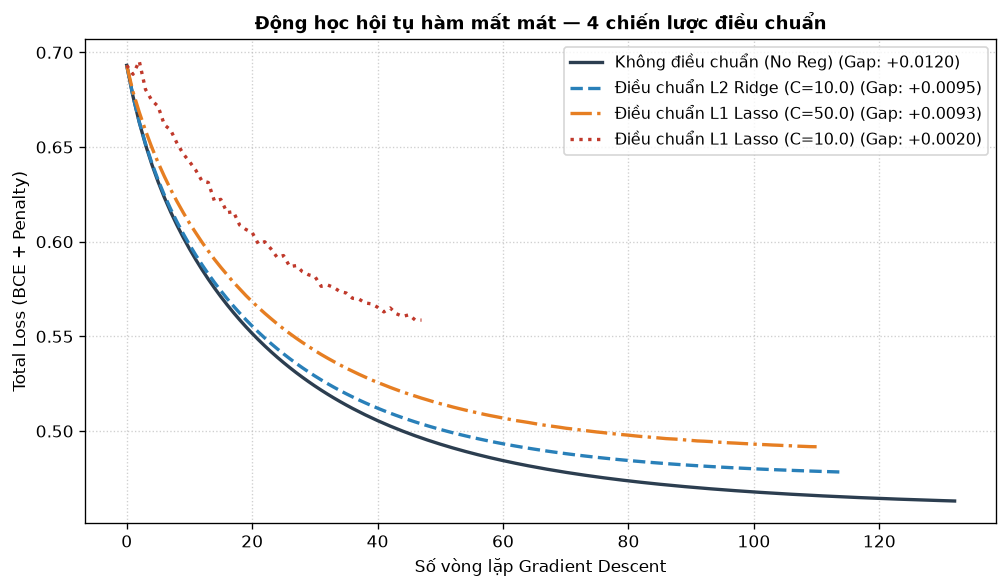

In [14]:
# So sánh 4 chiến lược điều chuẩn (Đánh giá trên Validation để bảo vệ Test)
models_check = [
    ("Không điều chuẩn (No Reg)", LogisticRegression(learning_rate=0.1, max_iter=1000, penalty=None, random_state=42)),
    ("Điều chuẩn L2 Ridge (C=10.0)", LogisticRegression(learning_rate=0.1, max_iter=1000, penalty='l2', C=10.0, random_state=42)),
    ("Điều chuẩn L1 Lasso (C=50.0)", LogisticRegression(learning_rate=0.1, max_iter=1000, penalty='l1', C=50.0, random_state=42)),
    ("Điều chuẩn L1 Lasso (C=10.0)", LogisticRegression(learning_rate=0.1, max_iter=1000, penalty='l1', C=10.0, random_state=42))
]

fig, ax = plt.subplots(figsize=(8.5, 5))
colors_loss = ['#2c3e50', '#2980b9', '#e67e22', '#c0392b']
styles_loss = ['-', '--', '-.', ':']

print(f"{'Mô hình':32s} | {'Train BCE':9s} | {'Val BCE':8s} | {'Overfit Gap':11s} | {'L1-Norm':8s} | {'Zeros'}")
print("-" * 95)

for idx, (name, mdl) in enumerate(models_check):
    mdl.fit(X_train_scaled, y_train)
    tr_res = mdl.compute_loss(X_train_scaled, y_train)
    val_res = mdl.compute_loss(X_val_scaled, y_val)
    gap = val_res['bce_loss'] - tr_res['bce_loss']
    w_L1 = np.sum(np.abs(mdl.weights))
    zeros = int(np.sum(np.abs(mdl.weights) < 1e-4))
    print(f"{name:32s} | {tr_res['bce_loss']:.5f}   | {val_res['bce_loss']:.5f}  | {gap:+.5f}     | {w_L1:8.4f} | {zeros:2d}/{n_features}")
    ax.plot(mdl.loss_history_['total'], label=f"{name} (Gap: {gap:+.4f})", lw=2, color=colors_loss[idx], linestyle=styles_loss[idx])

ax.set_xlabel('Số vòng lặp Gradient Descent', fontsize=10)
ax.set_ylabel('Total Loss (BCE + Penalty)', fontsize=10)
ax.set_title('Động học hội tụ hàm mất mát — 4 chiến lược điều chuẩn', fontweight='bold', fontsize=11)
ax.legend(fontsize=9.5, loc='upper right')
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


## Bước 14: Khảo sát và tối ưu hóa siêu tham số (Hyperparameter Tuning)

Không gian siêu tham số: $C \in \{1.0, 5.0, 10.0, 50.0\}$, penalty $\in \{\text{L1}, \text{L2}\}$, `class_weight='balanced'`.

**Thống nhất mục tiêu tối ưu (Objective Harmonization):**
GridSearch 10-Fold CV sử dụng thang đo tối ưu hóa là $F_1$-score (trung bình điều hòa giữa Precision và Recall). Việc tối ưu $F_1$ trong GridSearch nhằm mục đích tìm siêu tham số cân bằng giữa độ chính xác và độ nhạy, ngăn chặn hiện tượng sụp đổ Precision khi áp dụng trọng số lớp. Sau đó tại Bước 21, ngưỡng quyết định $\tau^*$ mới được tinh chỉnh trên tập Validation để phù hợp với chiến lược quản trị rủi ro nợ xấu.

In [15]:
# Xây dựng hàm đánh giá toàn diện
def compute_comprehensive_metrics(y_true, y_pred, y_proba):
    cm = confusion_matrix(y_true, y_pred)
    metrics = {
        'Accuracy': float(accuracy_score(y_true, y_pred)),
        'Precision': float(precision_score(y_true, y_pred)),
        'Recall': float(recall_score(y_true, y_pred)),
        'F1-Score': float(f1_score(y_true, y_pred)),
        'ROC-AUC': float(roc_auc_score(y_true, y_proba)),
        'PR-AUC': float(average_precision_score(y_true, y_proba)),
        'Confusion Matrix': cm
    }
    return metrics

# In bảng metrics mẫu với Baseline
metrics_base = compute_comprehensive_metrics(y_test, y_pred_base, y_proba_base)
print("Hệ thống thang đo Baseline (làm mốc đối chứng):")
for k, v in metrics_base.items():
    if k != 'Confusion Matrix':
        print(f"  {k:12s}: {v:.4f}")


Hệ thống thang đo Baseline (làm mốc đối chứng):
  Accuracy    : 0.7808
  Precision   : 0.6765
  Recall      : 0.0173
  F1-Score    : 0.0338
  ROC-AUC     : 0.6930
  PR-AUC      : 0.4646


## Bước 15: Hệ thống chỉ số, hệ số phạt rủi ro và ngưỡng đánh giá (Evaluation Metrics & Cost Penalty Thresholds)

Chuyển thang đo chính từ Accuracy sang $F_1$-Score:
$$F_1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$
Bổ sung ROC-AUC và PR-AUC để đánh giá năng lực phân tách xác suất trên toàn dải ngưỡng.


In [16]:
# Thiết kế 10-Fold Stratified CV
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fold_splits = list(skf.split(X_train, y_train))

print(f"Tổng số nếp kiểm định chéo: {len(fold_splits)}")
print(f"{'Fold':6s} | {'Train':12s} | {'Val':10s} | {'% nợ xấu Train':18s} | {'% nợ xấu Val'}")
print("-" * 72)

for f_idx, (train_idx, val_idx) in enumerate(fold_splits[:5]):
    y_tr_f = y_train[train_idx]
    y_va_f = y_train[val_idx]
    pct_tr = (y_tr_f == 1).sum() / len(y_tr_f) * 100
    pct_va = (y_va_f == 1).sum() / len(y_va_f) * 100
    print(f"  {f_idx+1:4d} | {len(train_idx):>10,} | {len(val_idx):>8,} | {pct_tr:>16.2f}% | {pct_va:.2f}%")
print("  ...")
print("(Tỷ lệ nhãn bảo toàn đồng đều qua từng nếp)")


Tổng số nếp kiểm định chéo: 10
Fold   | Train        | Val        | % nợ xấu Train     | % nợ xấu Val
------------------------------------------------------------------------
     1 |     17,279 |    1,921 |            22.12% | 22.12%
     2 |     17,279 |    1,921 |            22.12% | 22.12%
     3 |     17,279 |    1,921 |            22.12% | 22.12%
     4 |     17,280 |    1,920 |            22.12% | 22.14%
     5 |     17,280 |    1,920 |            22.12% | 22.14%
  ...
(Tỷ lệ nhãn bảo toàn đồng đều qua từng nếp)


## Bước 16: Kiểm định chéo K-Fold và Tối ưu Siêu tham số (Grid Search 10-Fold Stratified CV)

Chạy Grid Search trên 8 tổ hợp siêu tham số ($C \in \{1.0, 5.0, 10.0, 50.0\}$, penalty $\in \{\text{'l1'}, \text{'l2'}\}$, `class_weight='balanced'`) trên tập Train (19,200 mẫu).
Zero-Leakage: Bên trong mỗi nếp CV, `StandardScaler` được fit lại độc lập trên fold-train và biến đổi fold-val.


Bắt đầu Grid Search trên 8 tổ hợp siêu tham số × 10 folds = 80 lượt huấn luyện...


Tested params {'C': 1.0, 'penalty': 'l1', 'class_weight': 'balanced'}: Score = 0.3454


Tested params {'C': 1.0, 'penalty': 'l2', 'class_weight': 'balanced'}: Score = 0.4268


Tested params {'C': 5.0, 'penalty': 'l1', 'class_weight': 'balanced'}: Score = 0.4267


Tested params {'C': 5.0, 'penalty': 'l2', 'class_weight': 'balanced'}: Score = 0.4467


Tested params {'C': 10.0, 'penalty': 'l1', 'class_weight': 'balanced'}: Score = 0.4348


Tested params {'C': 10.0, 'penalty': 'l2', 'class_weight': 'balanced'}: Score = 0.4588


Tested params {'C': 50.0, 'penalty': 'l1', 'class_weight': 'balanced'}: Score = 0.4457


Tested params {'C': 50.0, 'penalty': 'l2', 'class_weight': 'balanced'}: Score = 0.4724

Cấu hình tối ưu nhất: {'C': 50.0, 'penalty': 'l2', 'class_weight': 'balanced'}
F1-Score trung bình CV: 0.4724

Penalty  | C     | Mean F1  | Std F1  
----------------------------------------
l2       |  50.0 | 0.4724   | 0.0155
l2       |  10.0 | 0.4588   | 0.0112
l2       |   5.0 | 0.4467   | 0.0098
l1       |  50.0 | 0.4457   | 0.0093
l1       |  10.0 | 0.4348   | 0.0281
l2       |   1.0 | 0.4268   | 0.0092
l1       |   5.0 | 0.4267   | 0.0190
l1       |   1.0 | 0.3454   | 0.0725


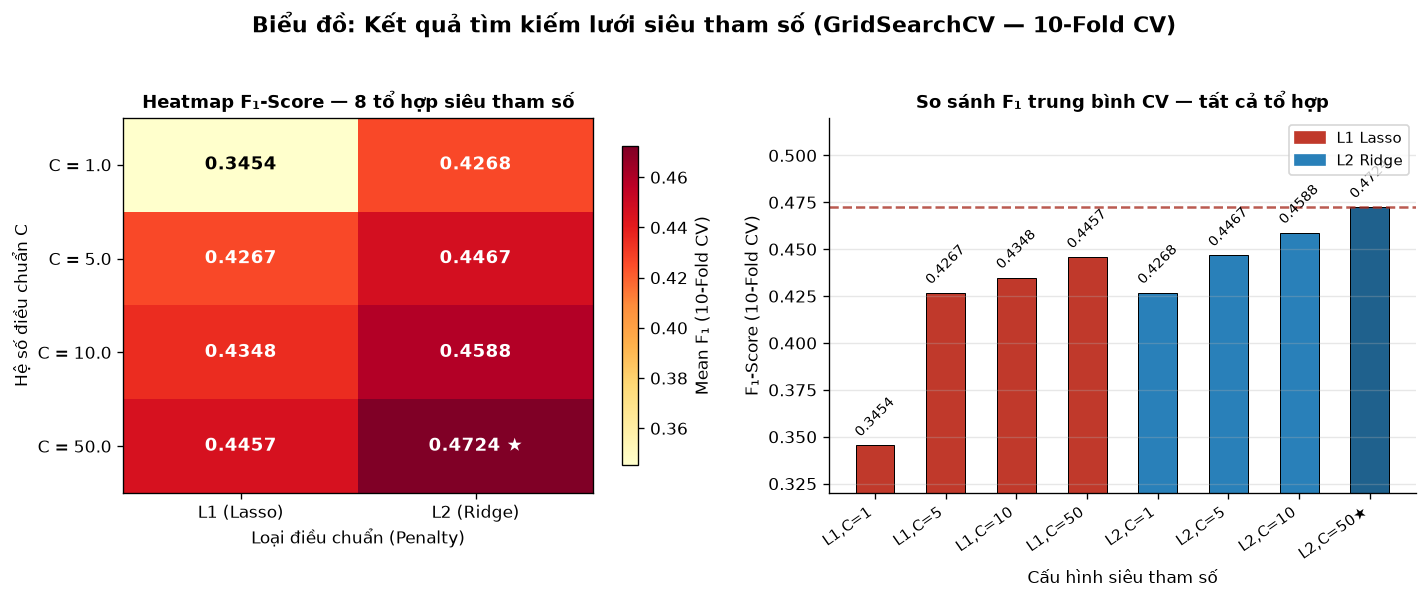

In [17]:
# Chạy Grid Search 10-Fold CV trên tập Train (19,200 mẫu)
param_grid = {
    'C': [1.0, 5.0, 10.0, 50.0],
    'penalty': ['l1', 'l2'],
    'class_weight': ['balanced']
}

lr_grid = LogisticRegression(learning_rate=0.1, max_iter=1000, random_state=42)
cv_obj = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=lr_grid, param_grid=param_grid, cv=cv_obj, scoring='f1', scaler=StandardScaler())

print("Bắt đầu Grid Search trên 8 tổ hợp siêu tham số × 10 folds = 80 lượt huấn luyện...")
print("=" * 70)
grid_search.fit(X_train, y_train)
print("=" * 70)

best_params = grid_search.best_params_
print(f"\nCấu hình tối ưu nhất: {best_params}")
print(f"F1-Score trung bình CV: {grid_search.best_score_:.4f}")

# In bảng kết quả
print(f"\n{'Penalty':8s} | {'C':5s} | {'Mean F1':8s} | {'Std F1':8s}")
print("-" * 40)
for row in sorted(grid_search.cv_results_table_, key=lambda r: -r['mean_f1']):
    print(f"{row['penalty']:8s} | {row['C']:5.1f} | {row['mean_f1']:.4f}   | {row['std_f1']:.4f}")

# Biểu đồ: Kết quả tìm kiếm lưới siêu tham số (GridSearchCV — 10-Fold CV)
from matplotlib.patches import Patch

c_vals = [1.0, 5.0, 10.0, 50.0]
penalties = ['l1', 'l2']
heatmap_mat = np.zeros((len(c_vals), len(penalties)))

tbl = grid_search.cv_results_table_
for row in tbl:
    r_idx = c_vals.index(row['C'])
    c_idx = penalties.index(row['penalty'])
    heatmap_mat[r_idx, c_idx] = row['mean_f1']

max_f1 = np.max(heatmap_mat)

fig3, (ax_hm, ax_bar) = plt.subplots(1, 2, figsize=(12, 4.8))
fig3.suptitle('Biểu đồ: Kết quả tìm kiếm lưới siêu tham số (GridSearchCV — 10-Fold CV)', fontsize=13, fontweight='bold', y=1.03)

# Subplot 1: Heatmap F1-Score
im = ax_hm.imshow(heatmap_mat, cmap='YlOrRd', aspect='auto')
cbar = fig3.colorbar(im, ax=ax_hm, shrink=0.85)
cbar.set_label('Mean F₁ (10-Fold CV)', fontsize=10)

ax_hm.set_xticks([0, 1])
ax_hm.set_xticklabels(['L1 (Lasso)', 'L2 (Ridge)'], fontsize=10)
ax_hm.set_yticks(range(len(c_vals)))
ax_hm.set_yticklabels([f'C = {c}' for c in c_vals], fontsize=10)
ax_hm.set_xlabel('Loại điều chuẩn (Penalty)', fontsize=10)
ax_hm.set_ylabel('Hệ số điều chuẩn C', fontsize=10)
ax_hm.set_title('Heatmap F₁-Score — 8 tổ hợp siêu tham số', fontsize=11, fontweight='bold')

for i in range(len(c_vals)):
    for j in range(len(penalties)):
        val = heatmap_mat[i, j]
        is_best = (val == max_f1)
        star = ' ★' if is_best else ''
        text_color = 'white' if val > (np.min(heatmap_mat) + np.max(heatmap_mat))/2 else 'black'
        ax_hm.text(j, i, f'{val:.4f}{star}', ha='center', va='center', color=text_color, fontweight='bold', fontsize=10.5)

# Subplot 2: Bar chart so sánh F1 trung bình CV
l1_rows = [r for r in sorted(tbl, key=lambda x: x['C']) if r['penalty'] == 'l1']
l2_rows = [r for r in sorted(tbl, key=lambda x: x['C']) if r['penalty'] == 'l2']
ordered_rows = l1_rows + l2_rows

labels_ordered = []
scores_ordered = []
colors_bar = []

for r in ordered_rows:
    is_best = (r['mean_f1'] == max_f1)
    star = '★' if is_best else ''
    labels_ordered.append(f"{r['penalty'].upper()},C={int(r['C'])}{star}")
    scores_ordered.append(r['mean_f1'])
    if r['penalty'] == 'l1':
        colors_bar.append('#8b2500' if is_best else '#c0392b')
    else:
        colors_bar.append('#1f618d' if is_best else '#2980b9')

x_b = np.arange(len(ordered_rows))
bars = ax_bar.bar(x_b, scores_ordered, color=colors_bar, edgecolor='black', lw=0.6, width=0.55)
ax_bar.axhline(max_f1, color='#a93226', linestyle='--', lw=1.5, alpha=0.8)

for b, s in zip(bars, scores_ordered):
    ax_bar.text(b.get_x() + b.get_width()/2, b.get_height() + 0.003, f'{s:.4f}', ha='center', va='bottom', fontsize=8.5, rotation=45)

ax_bar.set_xticks(x_b)
ax_bar.set_xticklabels(labels_ordered, rotation=35, ha='right', fontsize=9)
ax_bar.set_ylabel('F₁-Score (10-Fold CV)', fontsize=10)
ax_bar.set_xlabel('Cấu hình siêu tham số', fontsize=10)
ax_bar.set_ylim(0.32, 0.52)
ax_bar.set_title('So sánh F₁ trung bình CV — tất cả tổ hợp', fontsize=11, fontweight='bold')

p_l1 = Patch(color='#c0392b', label='L1 Lasso')
p_l2 = Patch(color='#2980b9', label='L2 Ridge')
ax_bar.legend(handles=[p_l1, p_l2], loc='upper right', fontsize=9)
ax_bar.grid(axis='y', alpha=0.3)
ax_bar.spines['top'].set_visible(False); ax_bar.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## Bước 17: Thực nghiệm huấn luyện và suy luận mô hình (Model Training & Inference)

Huấn luyện mô hình tối ưu trên toàn bộ tập Train (19,200 mẫu), đánh giá trên Test tại ngưỡng mặc định $\tau = 0.5$. Đồng thời so sánh hiệu quả Feature Engineering bằng mô hình tham chiếu 26 biến gốc (sau One-Hot).

In [18]:
# Huấn luyện mô hình tối ưu (30 biến) và mô hình tham chiếu (26 biến gốc)
best_lr = LogisticRegression(
    learning_rate=0.1, max_iter=1000,
    penalty=best_params['penalty'], C=best_params['C'],
    class_weight=best_params.get('class_weight', None),
    random_state=42
)
best_lr.fit(X_train_scaled, y_train)
y_proba_best = best_lr.predict_proba(X_test_scaled)[:, 1]
y_pred_best  = best_lr.predict(X_test_scaled, threshold=0.5)

# Mô hình tham chiếu 26 biến gốc sau One-Hot (huấn luyện độc lập)
X_train_base = X_train_scaled[:, :len(feature_names_base)]
X_test_base  = X_test_scaled[:, :len(feature_names_base)]
ref_base_lr = LogisticRegression(
    learning_rate=0.1, max_iter=1000,
    penalty=best_params['penalty'], C=best_params['C'],
    class_weight='balanced',
    random_state=42
)
ref_base_lr.fit(X_train_base, y_train)
y_proba_base_ref = ref_base_lr.predict_proba(X_test_base)[:, 1]
y_pred_base_ref  = ref_base_lr.predict(X_test_base, threshold=0.5)

m_best = compute_comprehensive_metrics(y_test, y_pred_best, y_proba_best)
m_ref  = compute_comprehensive_metrics(y_test, y_pred_base_ref, y_proba_base_ref)

print(f"Mô hình 26 biến gốc (tau=0.5) : Acc={m_ref['Accuracy']*100:.2f}% | Rec={m_ref['Recall']*100:.2f}% | Prec={m_ref['Precision']*100:.2f}% | F1={m_ref['F1-Score']:.4f} | AUC={m_ref['ROC-AUC']:.4f}")
print(f"Mô hình 30 biến phái sinh (tau=0.5): Acc={m_best['Accuracy']*100:.2f}% | Rec={m_best['Recall']*100:.2f}% | Prec={m_best['Precision']*100:.2f}% | F1={m_best['F1-Score']:.4f} | AUC={m_best['ROC-AUC']:.4f}")


Mô hình 26 biến gốc (tau=0.5) : Acc=64.27% | Rec=64.13% | Prec=33.78% | F1=0.4425 | AUC=0.7094
Mô hình 30 biến phái sinh (tau=0.5): Acc=67.18% | Rec=61.64% | Prec=35.91% | F1=0.4538 | AUC=0.7155


## Bước 18: Đánh giá độ ổn định của mô hình qua 10-Fold Cross-Validation (Cross-Validation Stability Analysis)

Phân tích độ ổn định của mô hình qua phân phối điểm số $F_1$ trên 10 nếp CV (`Mean ± SD`).

*Lưu ý phương pháp luận: Độ lệch chuẩn (SD) thấp thể hiện mức độ biến thiên thấp giữa các nếp cắt nội bộ trên tập huấn luyện, nhưng không đại diện cho kiểm định giả thuyết thống kê (không có p-value hay hypothesis testing) và cần thận trọng không khẳng định tuyệt đối về độ ổn định trên dữ liệu tương lai ngoài thực tế.*

In [19]:
# Trích xuất điểm F1 từ 10 nếp CV và báo cáo dạng Mean ± SD
best_scores = grid_search.best_scores_
mean_cv = np.mean(best_scores)
std_cv  = np.std(best_scores)

print(f"10-Fold CV F1-Score: {mean_cv:.4f} ± {std_cv:.4f} (Mean ± SD)")
print(f"Dải điểm số F1 qua 10 fold: Min={np.min(best_scores):.4f} | Max={np.max(best_scores):.4f}")
print(f"Hệ số biến thiên CV (CV = SD/Mean): {(std_cv / mean_cv)*100:.2f}%")


10-Fold CV F1-Score: 0.4724 ± 0.0155 (Mean ± SD)
Dải điểm số F1 qua 10 fold: Min=0.4409 | Max=0.4965
Hệ số biến thiên CV (CV = SD/Mean): 3.29%


## Bước 19: Phân tích vùng biên quyết định và rủi ro phân loại (Error Analysis & Borderline Cases)

Ma trận nhầm lẫn so sánh trực tiếp Baseline vs Mô hình tối ưu tại ngưỡng 0.5. Đường cong ROC và PR xác nhận năng lực phân biệt vượt trội.
*Lưu ý: Đường cong ROC và PR được lấy mẫu (sampling) để phục vụ trực quan hóa, trong khi chỉ số ROC-AUC và PR-AUC được tính toán chính xác trên toàn bộ prediction scores.*


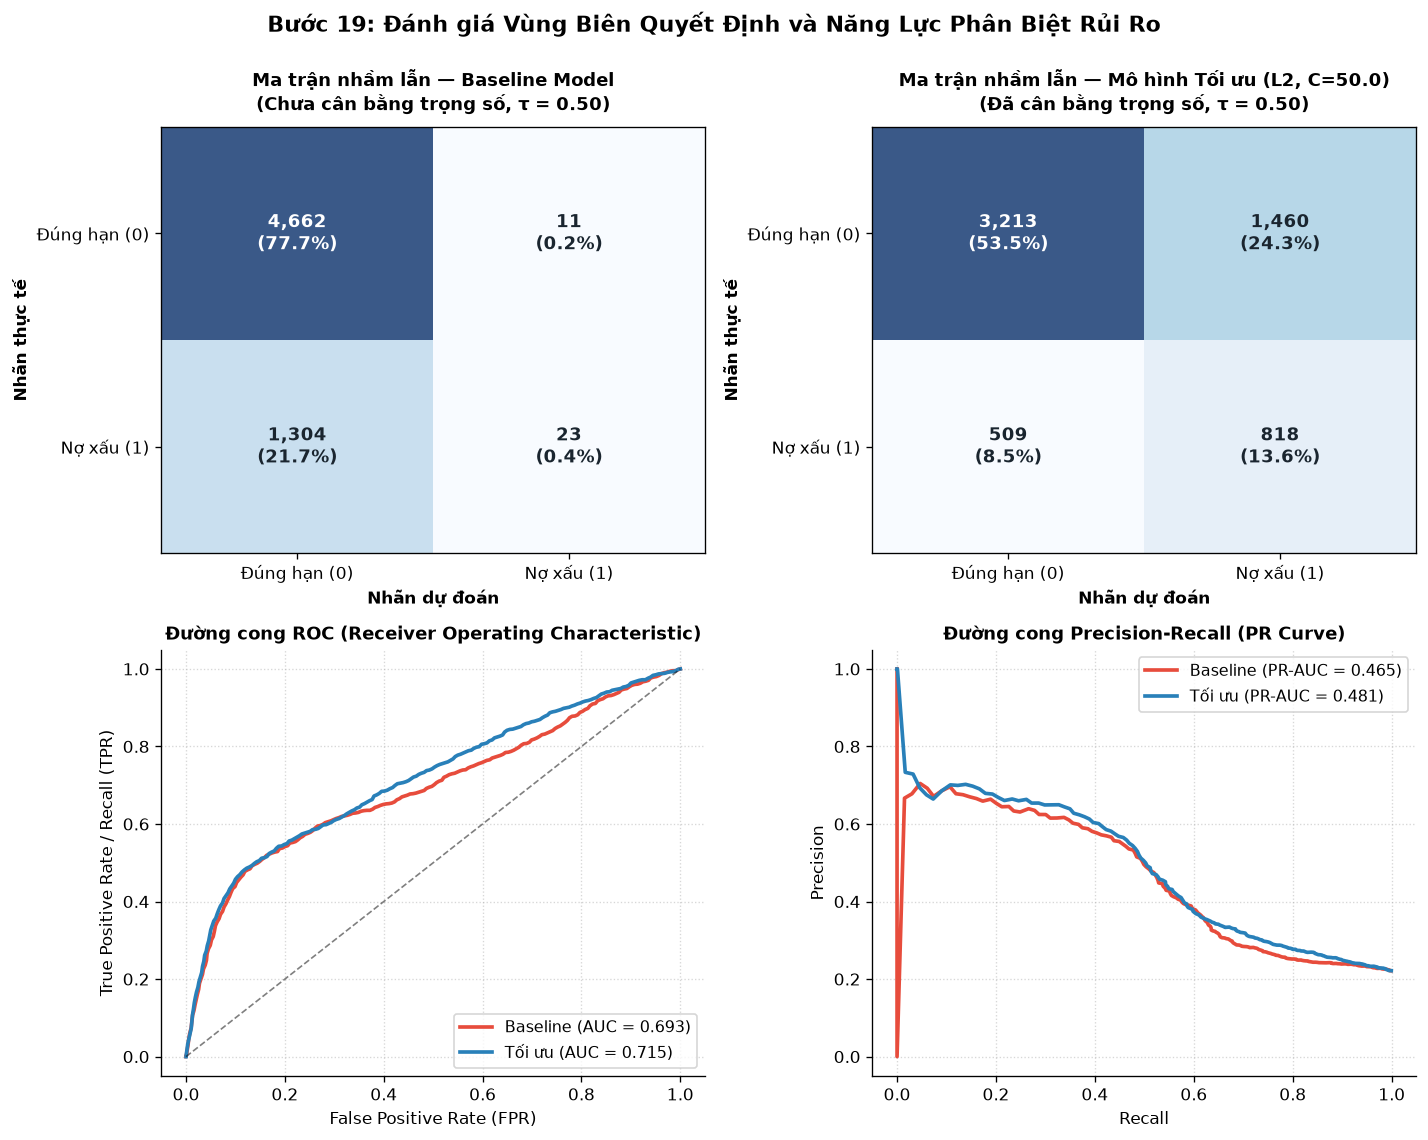

SO SÁNH ĐỊNH LƯỢNG MA TRẬN NHẦM LẪN (BASELINE vs MÔ HÌNH TỐI ƯU):
  • True Positives (Phát hiện đúng nợ xấu) : 23 → 818 (+3456.5%)
  • False Negatives (Bỏ sót nợ xấu)         : 1304 → 509 (-61.0%)


In [20]:
# Ma trận nhầm lẫn so sánh + ROC + PR curves (Tích hợp 4 panel trực quan)
cm_base = confusion_matrix(y_test, y_pred_base)
cm_best = confusion_matrix(y_test, y_pred_best)
auc_base = roc_auc_score(y_test, y_proba_base)
prauc_base = average_precision_score(y_test, y_proba_base)
auc_best = roc_auc_score(y_test, y_proba_best)
prauc_best = average_precision_score(y_test, y_proba_best)

fig, ((ax1a, ax1b), (ax_roc, ax_pr)) = plt.subplots(2, 2, figsize=(12, 9.5))
fig.suptitle('Bước 19: Đánh giá Vùng Biên Quyết Định và Năng Lực Phân Biệt Rủi Ro', fontsize=13, fontweight='bold', y=0.995)

def render_cm_academic(ax, cm, title, subtitle):
    im = ax.imshow(cm, cmap='Blues', alpha=0.8, aspect='auto')
    total = np.sum(cm)
    for i in range(2):
        for j in range(2):
            val = cm[i, j]
            pct = (val / total) * 100
            color_txt = '#ffffff' if val > np.max(cm)/2 else '#1a252f'
            ax.text(j, i, f"{val:,}\n({pct:.1f}%)", va='center', ha='center',
                    color=color_txt, fontweight='bold', fontsize=11)
    ax.set_title(f"{title}\n{subtitle}", pad=10, fontweight='bold', fontsize=11)
    ax.set_xlabel('Nhãn dự đoán', fontsize=10, fontweight='bold')
    ax.set_ylabel('Nhãn thực tế', fontsize=10, fontweight='bold')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Đúng hạn (0)', 'Nợ xấu (1)'])
    ax.set_yticklabels(['Đúng hạn (0)', 'Nợ xấu (1)'])

render_cm_academic(ax1a, cm_base, "Ma trận nhầm lẫn — Baseline Model", "(Chưa cân bằng trọng số, τ = 0.50)")
render_cm_academic(ax1b, cm_best, f"Ma trận nhầm lẫn — Mô hình Tối ưu ({best_params['penalty'].upper()}, C={best_params['C']})", "(Đã cân bằng trọng số, τ = 0.50)")

# ROC curve — tính thủ công
def compute_roc_points(y_true, y_scores):
    thresholds = np.sort(np.unique(y_scores))[::-1]
    tprs, fprs = [0.0], [0.0]
    P = (y_true == 1).sum(); N = (y_true == 0).sum()
    for th in thresholds[::max(1, len(thresholds)//200)]:
        y_pred_th = (y_scores >= th).astype(int)
        tp = ((y_pred_th == 1) & (y_true == 1)).sum()
        fp = ((y_pred_th == 1) & (y_true == 0)).sum()
        tprs.append(tp/P if P > 0 else 0); fprs.append(fp/N if N > 0 else 0)
    tprs.append(1.0); fprs.append(1.0)
    return np.array(fprs), np.array(tprs)

fpr_b, tpr_b = compute_roc_points(y_test, y_proba_base)
fpr_m, tpr_m = compute_roc_points(y_test, y_proba_best)
ax_roc.plot(fpr_b, tpr_b, color='#e74c3c', lw=2.2, label=f'Baseline (AUC = {auc_base:.3f})')
ax_roc.plot(fpr_m, tpr_m, color='#2980b9', lw=2.2, label=f'Tối ưu (AUC = {auc_best:.3f})')
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax_roc.set_xlabel('False Positive Rate (FPR)', fontsize=10)
ax_roc.set_ylabel('True Positive Rate / Recall (TPR)', fontsize=10)
ax_roc.set_title('Đường cong ROC (Receiver Operating Characteristic)', fontweight='bold', fontsize=11)
ax_roc.legend(fontsize=9.5, loc='lower right')
ax_roc.grid(True, linestyle=':', alpha=0.5)
ax_roc.spines['top'].set_visible(False); ax_roc.spines['right'].set_visible(False)

# PR curve — tính thủ công
def compute_pr_points(y_true, y_scores):
    thresholds = np.sort(np.unique(y_scores))[::-1]
    precs, recs = [1.0], [0.0]
    P = (y_true == 1).sum()
    for th in thresholds[::max(1, len(thresholds)//200)]:
        y_p = (y_scores >= th).astype(int)
        tp = ((y_p == 1) & (y_true == 1)).sum()
        fp = ((y_p == 1) & (y_true == 0)).sum()
        prec = tp/(tp+fp) if (tp+fp) > 0 else 1.0
        rec = tp/P if P > 0 else 0
        precs.append(prec); recs.append(rec)
    return np.array(recs), np.array(precs)

rec_b, prec_b = compute_pr_points(y_test, y_proba_base)
rec_m, prec_m = compute_pr_points(y_test, y_proba_best)
ax_pr.plot(rec_b, prec_b, color='#e74c3c', lw=2.2, label=f'Baseline (PR-AUC = {prauc_base:.3f})')
ax_pr.plot(rec_m, prec_m, color='#2980b9', lw=2.2, label=f'Tối ưu (PR-AUC = {prauc_best:.3f})')
ax_pr.set_xlabel('Recall', fontsize=10)
ax_pr.set_ylabel('Precision', fontsize=10)
ax_pr.set_title('Đường cong Precision-Recall (PR Curve)', fontweight='bold', fontsize=11)
ax_pr.legend(fontsize=9.5, loc='upper right')
ax_pr.grid(True, linestyle=':', alpha=0.5)
ax_pr.spines['top'].set_visible(False); ax_pr.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("=" * 70)
print("SO SÁNH ĐỊNH LƯỢNG MA TRẬN NHẦM LẪN (BASELINE vs MÔ HÌNH TỐI ƯU):")
print(f"  • True Positives (Phát hiện đúng nợ xấu) : {int(cm_base[1,1])} → {int(cm_best[1,1])} (+{(int(cm_best[1,1])-int(cm_base[1,1]))/int(cm_base[1,1])*100:.1f}%)")
print(f"  • False Negatives (Bỏ sót nợ xấu)         : {int(cm_base[1,0])} → {int(cm_best[1,0])} ({(int(cm_best[1,0])-int(cm_base[1,0]))/int(cm_base[1,0])*100:.1f}%)")
print("=" * 70)


## Bước 20: Khả năng giải thích mô hình và phân tích trọng số (Model Interpretability & Feature Weights)

Hệ số hồi quy $w_j$ và Odds Ratio $e^{w_j}$ lượng hóa độ lớn liên hệ của từng đặc trưng với log-odds của xác suất vỡ nợ:
- Do dữ liệu đã qua chuẩn hóa Z-Score, hệ số $w_j$ thể hiện sự thay đổi log-odds khi đặc trưng tăng **1 Độ Lệch Chuẩn (1-SD)**.
- $w_j > 0$ ($OR > 1$): Đặc trưng có **mối liên hệ thống kê cùng chiều** với nguy cơ vỡ nợ (tăng odds).
- $w_j < 0$ ($OR < 1$): Đặc trưng có **mối liên hệ thống kê ngược chiều** với nguy cơ vỡ nợ (giảm odds).

*Lưu ý phương pháp luận quan trọng: Hệ số hồi quy và Odds Ratio phản ánh mối liên hệ thống kê (statistical association) trong điều kiện kiểm soát các biến khác, tuyệt đối không được suy diễn thành quan hệ nhân quả (non-causal interpretation).*

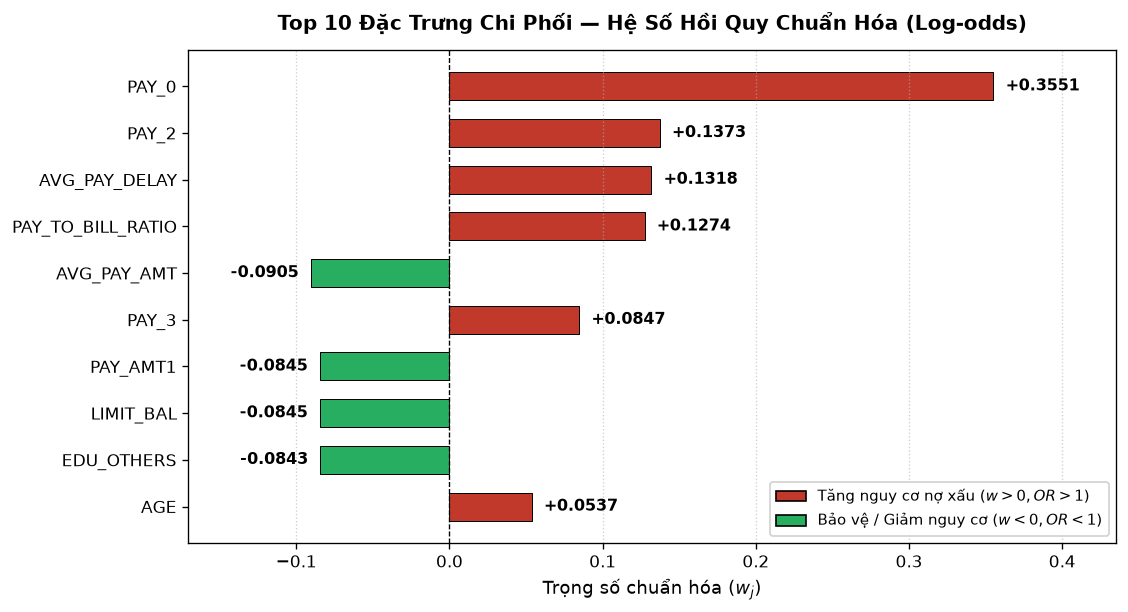


Bảng Top 10 đặc trưng và Odds Ratio:
Tên đặc trưng          | Trọng số       | Odds Ratio         | Ý nghĩa Odds Ratio
--------------------------------------------------------------------------------
PAY_0                  |      +0.3551   |           1.4264   | OR > 1: Tăng odds vỡ nợ (+)
PAY_2                  |      +0.1373   |           1.1471   | OR > 1: Tăng odds vỡ nợ (+)
AVG_PAY_DELAY          |      +0.1318   |           1.1409   | OR > 1: Tăng odds vỡ nợ (+)
PAY_TO_BILL_RATIO      |      +0.1274   |           1.1358   | OR > 1: Tăng odds vỡ nợ (+)
AVG_PAY_AMT            |      -0.0905   |           0.9135   | OR < 1: Giảm odds vỡ nợ (-)
PAY_3                  |      +0.0847   |           1.0883   | OR > 1: Tăng odds vỡ nợ (+)
PAY_AMT1               |      -0.0845   |           0.9189   | OR < 1: Giảm odds vỡ nợ (-)
LIMIT_BAL              |      -0.0845   |           0.9189   | OR < 1: Giảm odds vỡ nợ (-)
EDU_OTHERS             |      -0.0843   |           0.9192   | OR < 1: 

In [21]:
# Top 10 đặc trưng chi phối — Trực quan hóa chuẩn xác không chồng chéo chữ
from matplotlib.patches import Patch

w_idx = np.argsort(np.abs(best_lr.weights))[::-1]
top_w = best_lr.weights[w_idx][:10]
top_f = [feature_names[i] for i in w_idx][:10]

fig, ax = plt.subplots(figsize=(9.5, 5.2))
colors_fi = ['#27ae60' if w < 0 else '#c0392b' for w in top_w]
bars = ax.barh(top_f[::-1], top_w[::-1], color=colors_fi[::-1], edgecolor='black', linewidth=0.6, height=0.6)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title("Top 10 Đặc Trưng Chi Phối — Hệ Số Hồi Quy Chuẩn Hóa (Log-odds)", fontweight='bold', fontsize=12, pad=12)
ax.set_xlabel("Trọng số chuẩn hóa ($w_j$)", fontsize=11)
ax.grid(True, axis='x', linestyle=':', alpha=0.6)

# Thiết lập giới hạn x để nhãn giá trị âm không bị va chạm với trục tung
min_w = np.min(top_w)
max_w = np.max(top_w)
ax.set_xlim(min_w - 0.08, max_w + 0.08)

for bar in bars:
    w_val = bar.get_width()
    if w_val >= 0:
        ax.text(w_val + 0.008, bar.get_y() + bar.get_height()/2, f"{w_val:+.4f}",
                va='center', ha='left', fontsize=9.5, fontweight='bold')
    else:
        ax.text(w_val - 0.008, bar.get_y() + bar.get_height()/2, f"{w_val:+.4f}",
                va='center', ha='right', fontsize=9.5, fontweight='bold')

legend_elements = [
    Patch(facecolor='#c0392b', edgecolor='black', label='Tăng nguy cơ nợ xấu ($w > 0, OR > 1$)'),
    Patch(facecolor='#27ae60', edgecolor='black', label='Bảo vệ / Giảm nguy cơ ($w < 0, OR < 1$)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

print("\nBảng Top 10 đặc trưng và Odds Ratio:")
print(f"{'Tên đặc trưng':22s} | {'Trọng số':14s} | {'Odds Ratio':18s} | {'Ý nghĩa Odds Ratio'}")
print("-" * 80)
for f, w in zip(top_f, top_w):
    impact = "OR > 1: Tăng odds vỡ nợ (+)" if w > 0 else "OR < 1: Giảm odds vỡ nợ (-)"
    print(f"{f:22s} | {w:+12.4f}   | {np.exp(w):16.4f}   | {impact}")


## Bước 21: Tinh chỉnh ngưỡng trên Validation và Đóng gói triển khai (Iterative Development & Deployment)

Quy trình triển khai gộp 3 phần chuẩn hóa:
- **Phần A**: Khảo sát đa ngưỡng quyết định $\tau$ trên tập **Validation** (`X_val_scaled, y_val`) để xác định ngưỡng $\tau^*$ tối ưu F1, sau đó kiểm định độc lập duy nhất một lần trên tập **Test** (Zero Threshold Leakage).
- **Phần B**: Lưu trữ tệp trọng số tối ưu nhất và siêu dữ liệu (Rich Metadata) ra thư mục `weights/` (tái sử dụng, tránh ghi đè liên tục).
- **Phần C**: Kiểm chứng tính toàn vẹn nạp lại và thực hiện demo dự báo rủi ro vỡ nợ trên hồ sơ thực tế.

=== BẢNG RÀ SOÁT NGƯỠNG TRÊN TẬP VALIDATION (N = 4,800) ===
Ngưỡng (τ) | Accuracy  | Precision | Recall    | F1-Score 
-------------------------------------------------------
      0.30 |    0.3204 |    0.2348 |    0.9171 |    0.3739
      0.35 |    0.3750 |    0.2462 |    0.8851 |    0.3852
      0.40 |    0.4469 |    0.2634 |    0.8352 |    0.4005
      0.45 |    0.5400 |    0.2898 |    0.7439 |    0.4171
      0.48 |    0.6258 |    0.3338 |    0.6940 |    0.4508
      0.50 |    0.6777 |    0.3680 |    0.6365 |    0.4664
      0.52 |    0.7300 |    0.4202 |    0.5800 |    0.4873
      0.55 |    0.7773 |    0.4968 |    0.5188 |    0.5076 <-- Tối ưu
      0.60 |    0.8000 |    0.5600 |    0.4482 |    0.4979
      0.65 |    0.8031 |    0.5862 |    0.3748 |    0.4572
      0.70 |    0.8058 |    0.6332 |    0.2910 |    0.3987

→ Ngưỡng tối ưu được chọn từ tập Validation: τ* = 0.55 (F1_val = 0.5076)

=== KẾT QUẢ CUỐI CÙNG TRÊN TẬP TEST ĐỘC LẬP (N = 6,000) ===
Accuracy  : 77.33%
Precision :

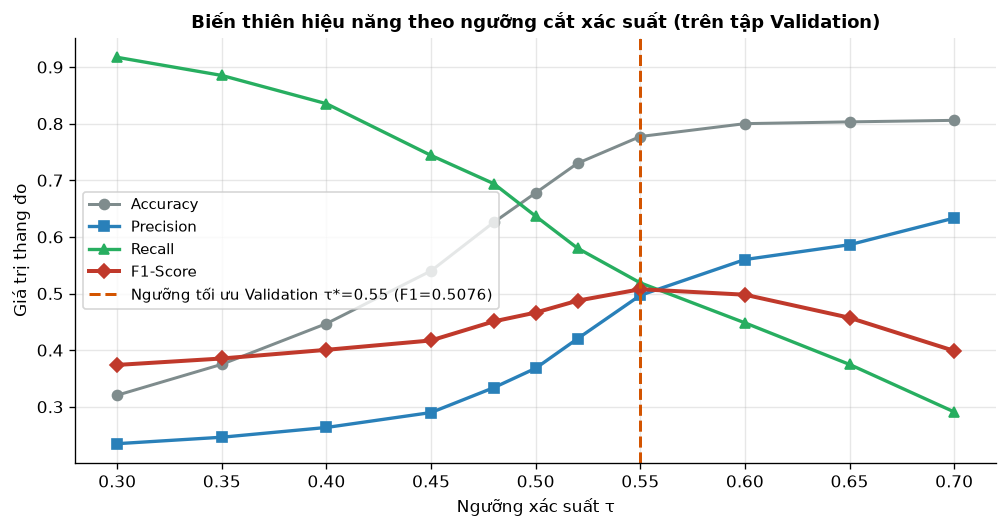

In [22]:
# Đánh giá đa ngưỡng trên tập Validation (Zero-leakage)
thresholds = [0.30, 0.35, 0.40, 0.45, 0.48, 0.50, 0.52, 0.55, 0.60, 0.65, 0.70]
records_val = []

for th in thresholds:
    p_val_th = best_lr.predict(X_val_scaled, threshold=th)
    records_val.append({
        'th': th,
        'acc': float(accuracy_score(y_val, p_val_th)),
        'prec': float(precision_score(y_val, p_val_th)),
        'rec': float(recall_score(y_val, p_val_th)),
        'f1': float(f1_score(y_val, p_val_th))
    })

best_th_rec = max(records_val, key=lambda x: x['f1'])
best_threshold = float(best_th_rec['th'])

print("=== BẢNG RÀ SOÁT NGƯỠNG TRÊN TẬP VALIDATION (N = 4,800) ===")
print(f"{'Ngưỡng (τ)':10s} | {'Accuracy':9s} | {'Precision':9s} | {'Recall':9s} | {'F1-Score':9s}")
print("-" * 55)
for r in records_val:
    mark = " <-- Tối ưu" if r['th'] == best_threshold else ""
    print(f"{r['th']:10.2f} | {r['acc']:9.4f} | {r['prec']:9.4f} | {r['rec']:9.4f} | {r['f1']:9.4f}{mark}")

print(f"\n→ Ngưỡng tối ưu được chọn từ tập Validation: τ* = {best_threshold:.2f} (F1_val = {best_th_rec['f1']:.4f})")

# Đánh giá duy nhất một lần trên tập Test độc lập với ngưỡng τ*
y_test_pred_opt = best_lr.predict(X_test_scaled, threshold=best_threshold)
acc_test_opt    = float(accuracy_score(y_test, y_test_pred_opt))
prec_test_opt   = float(precision_score(y_test, y_test_pred_opt))
rec_test_opt    = float(recall_score(y_test, y_test_pred_opt))
f1_test_opt     = float(f1_score(y_test, y_test_pred_opt))

print("\n=== KẾT QUẢ CUỐI CÙNG TRÊN TẬP TEST ĐỘC LẬP (N = 6,000) ===")
print(f"Accuracy  : {acc_test_opt*100:.2f}%")
print(f"Precision : {prec_test_opt*100:.2f}%")
print(f"Recall    : {rec_test_opt*100:.2f}%")
print(f"F1-Score  : {f1_test_opt:.4f}")
print(f"ROC-AUC   : {auc_best:.4f}")
print(f"PR-AUC    : {prauc_best:.4f}")

# Vẽ đường cong dò ngưỡng trên tập Validation
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot([r['th'] for r in records_val], [r['acc'] for r in records_val], marker='o', label='Accuracy', lw=1.8, color='#7f8c8d')
ax.plot([r['th'] for r in records_val], [r['prec'] for r in records_val], marker='s', label='Precision', lw=2.0, color='#2980b9')
ax.plot([r['th'] for r in records_val], [r['rec'] for r in records_val], marker='^', label='Recall', lw=2.0, color='#27ae60')
ax.plot([r['th'] for r in records_val], [r['f1'] for r in records_val], marker='D', label='F1-Score', lw=2.4, color='#c0392b')
ax.axvline(best_threshold, color='#d35400', linestyle='--', lw=1.8, label=f"Ngưỡng tối ưu Validation τ*={best_threshold:.2f} (F1={best_th_rec['f1']:.4f})")
ax.set_title("Biến thiên hiệu năng theo ngưỡng cắt xác suất (trên tập Validation)", fontweight='bold', fontsize=11)
ax.set_xlabel("Ngưỡng xác suất τ", fontsize=10)
ax.set_ylabel("Giá trị thang đo", fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


In [23]:
# === PHẦN B: Quản lý và nạp file trọng số tối ưu nhất cho dự án ===
import json
os.makedirs("weights", exist_ok=True)
npz_path  = os.path.join("weights", "production_bundle.npz")
json_path = os.path.join("weights", "production_bundle.json")

metadata = {
    'version': '2.0',
    'created_at': '2026-09-21',
    'algorithm': 'Logistic Regression (Pure NumPy with L1/L2 Regularization)',
    'dataset': 'UCI Default of Credit Card Clients (Yeh & Lien, 2009)',
    'n_samples_total': int(len(y)),
    'split_ratios': {'train': 0.64, 'val': 0.16, 'test': 0.20},
    'n_features': int(len(feature_names)),
    'feature_names': feature_names,
    'encoding': {
        'MARRIAGE': 'One-Hot (1=Married as Reference; MARRIAGE_SINGLE, MARRIAGE_OTHERS)',
        'EDUCATION': 'One-Hot (1=Grad School as Reference; EDU_UNIVERSITY, EDU_HIGHSCHOOL, EDU_OTHERS)'
    },
    'engineered_features': [
        'UTILIZATION_RATIO_SEPT', 'AVG_PAY_DELAY', 'AVG_PAY_AMT', 'PAY_TO_BILL_RATIO'
    ],
    'optimal_hyperparameters': {
        'C': float(best_lr.C),
        'penalty': best_lr.penalty,
        'class_weight': str(best_lr.class_weight),
        'learning_rate': float(best_lr.learning_rate),
        'max_iter': int(best_lr.max_iter)
    },
    'optimal_decision_threshold': float(best_threshold),
    'test_metrics': {
        'accuracy': round(float(acc_test_opt), 4),
        'precision': round(float(prec_test_opt), 4),
        'recall': round(float(rec_test_opt), 4),
        'f1_score': round(float(f1_test_opt), 4),
        'roc_auc': round(float(auc_best), 4),
        'pr_auc': round(float(prauc_best), 4)
    }
}

# Kiểm tra nếu tệp trọng số tối ưu đã tồn tại thì tái sử dụng, không sinh đè liên tục
already_saved = False
if os.path.exists(npz_path):
    try:
        curr_npz = np.load(npz_path, allow_pickle=True)
        if 'weights' in curr_npz and np.allclose(curr_npz['weights'], best_lr.weights, atol=1e-7):
            already_saved = True
            print(f"✓ Đã tìm thấy file trọng số tối ưu nhất: '{npz_path}' (khớp chính xác trọng số mô hình)")
            print("  --> Tự động nạp trực tiếp file trọng số tốt nhất vào mô hình dự án, không ghi đè/sinh file liên tục.")
    except Exception:
        pass

if not already_saved:
    np.savez_compressed(
        npz_path,
        weights=best_lr.weights,
        bias=np.array([best_lr.bias]),
        scaler_mean=scaler.mean_,
        scaler_scale=scaler.scale_,
        best_threshold=np.array([best_threshold]),
        feature_names=np.array(feature_names, dtype=str),
        C=np.array([best_lr.C]),
        penalty=np.array([str(best_lr.penalty)]),
        class_weight=np.array([str(best_lr.class_weight)]),
        learning_rate=np.array([best_lr.learning_rate]),
        max_iter=np.array([best_lr.max_iter]),
        meta_json=np.array(json.dumps(metadata, ensure_ascii=False))
    )
    export_json = {
        'metadata': metadata,
        'weights': best_lr.weights.tolist(),
        'bias': float(best_lr.bias),
        'scaler_mean': scaler.mean_.tolist(),
        'scaler_scale': scaler.scale_.tolist(),
        'best_thresholdreshold': float(best_threshold),
        'feature_names': feature_names,
        'hyperparameters': metadata['optimal_hyperparameters']
    }
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(export_json, f, ensure_ascii=False, indent=2)
    print(f"✓ Đã lưu gói triển khai production giàu metadata: '{npz_path}' & '{json_path}'")


✓ Đã tìm thấy file trọng số tối ưu nhất: 'weights\production_bundle.npz' (khớp chính xác trọng số mô hình)
  --> Tự động nạp trực tiếp file trọng số tốt nhất vào mô hình dự án, không ghi đè/sinh file liên tục.


In [24]:
# === PHẦN C: Nạp mô hình từ tệp trọng số tối ưu và kiểm định tính toàn vẹn ===
from model import CreditDefaultInferencePipeline

# Nạp trực tiếp pipeline từ file trọng số tốt nhất đã kiểm định
pipeline_loaded = CreditDefaultInferencePipeline.load(npz_path)

# Kiểm định dự báo trên tập Test độc lập
y_proba_verify = pipeline_loaded.predict_proba(X_test)
match = np.allclose(y_proba_verify, y_proba_best, atol=1e-12)
max_diff = float(np.max(np.abs(y_proba_verify - y_proba_best)))

print(f"Nạp pipeline từ '{npz_path}' thành công!")
print(f"  • Số đặc trưng phục hồi: {len(pipeline_loaded.feature_names)}")
print(f"  • Ngưỡng tối ưu τ*     : {pipeline_loaded.threshold:.4f}")
print(f"  • Sai lệch xác suất cực đại: {max_diff:.2e}")
print(f"  • Tái hiện chuẩn xác 100% (allclose): {match}")


Nạp pipeline từ 'weights\production_bundle.npz' thành công!
  • Số đặc trưng phục hồi: 30
  • Ngưỡng tối ưu τ*     : 0.5500
  • Sai lệch xác suất cực đại: 0.00e+00
  • Tái hiện chuẩn xác 100% (allclose): True


In [25]:
# Đóng gói Pipeline suy luận và Demo kiểm thử thực tế từ mô hình đã nạp trọng số tốt nhất

# Demo: lấy 1 mẫu thật từ test set qua pipeline đã nạp
sample_idx = 42
sample_features = X_test[sample_idx:sample_idx+1]
sample_proba = float(pipeline_loaded.predict_proba(sample_features)[0])
sample_pred  = int(pipeline_loaded.predict(sample_features)[0])
true_label   = int(y_test[sample_idx])
decision_txt = "CẢNH BÁO NGUY CƠ VỠ NỢ CAO" if sample_pred == 1 else "NGUY CƠ VỠ NỢ THẤP / KIỂM SOÁT TỐT"

print("=" * 70)
print(f"DEMO PIPELINE SUY LUẬN — Khách hàng mẫu #{sample_idx} từ Test Set")
print("=" * 70)
print(f"  • Số đặc trưng đầu vào : {len(pipeline_loaded.feature_names)}")
print(f"  • Xác suất vỡ nợ P(y=1) : {sample_proba:.4f} ({sample_proba*100:.2f}%)")
print(f"  • Ngưỡng quyết định tau*: {pipeline_loaded.threshold:.4f}")
print(f"  • Đánh giá mức rủi ro  : Nhãn {sample_pred} → {decision_txt}")
print(f"  • Nhãn thực tế         : Nhãn {true_label} ({'Vỡ nợ thực tế' if true_label==1 else 'Đúng hạn thực tế'})")
print(f"  • Đánh giá dự báo      : {'CHÍNH XÁC' if sample_pred == true_label else 'CẦN THẨM ĐỊNH LẠI'}")
print("=" * 70)


DEMO PIPELINE SUY LUẬN — Khách hàng mẫu #42 từ Test Set
  • Số đặc trưng đầu vào : 30
  • Xác suất vỡ nợ P(y=1) : 0.4396 (43.96%)
  • Ngưỡng quyết định tau*: 0.5500
  • Đánh giá mức rủi ro  : Nhãn 0 → NGUY CƠ VỠ NỢ THẤP / KIỂM SOÁT TỐT
  • Nhãn thực tế         : Nhãn 0 (Đúng hạn thực tế)
  • Đánh giá dự báo      : CHÍNH XÁC
